In [1]:
import os
import pandas as pd
import numpy as np 
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

C:\Users\marie\AppData\Local\Temp\ipykernel_17228\1426838226.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
dirpath = os.getcwd()
features_path = r"data\gmfeature_table.csv"
data_path = r"C:\Users\marie\rep_codes\udder_project\udder_analysis\long_format_df"
plot_dir = r"C:\Users\marie\rep_codes\udder_project\paper\revision_B\plots"

color_dict = {'lf': 'cyan', 'rf': 'skyblue', 'lb': 'royalblue', 'rb': 'dodgerblue', 'front':'cyan', 
             'right': 'skyblue', 'left': 'royalblue', 'back': 'dodgerblue', 'udder': 'plum'}

tick_map = {"udder":"udder", "lf": "left\nfront", "rf":"right\nfront", "lb": "left\nrear", "rb":"right\nrear", "right":"right", "left":"left", "front": "front", "back":"rear"}

In [3]:
data = pd.read_csv(features_path)

In [4]:
data

,cow,udder_vol,lf_vol,rf_vol,lb_vol,rb_vol,udder_sarea,lf_sarea,rf_sarea,lb_sarea,...,lb_circ,lb_exc,rb_peri,rb_area,rb_circ,rb_exc,lf_len,rf_len,lb_len,rb_len
0,627,6.742235,2.085106,2.320265,0.655287,0.907118,2202.840957,676.526869,710.606157,388.758950,...,0.753654,0.540129,NaN,NaN,0.718000,0.600890,37.991288,41.337529,42.078602,36.358942
1,723,5.866114,3.189081,1.988038,0.497105,0.565673,1557.547077,620.012292,569.962040,259.224542,...,0.603719,0.842961,477.782792,8966.5,NaN,0.815459,46.126468,47.956094,32.716431,NaN
2,729,NaN,5.068295,4.355240,0.786221,0.891771,NaN,NaN,998.056447,255.710493,...,0.670033,0.571781,422.107648,10422.0,0.740037,0.664880,NaN,60.757677,48.859144,37.343963
3,736,8.529069,5.034365,1.684315,1.298735,0.676856,2190.923732,1036.329523,415.856293,525.530135,...,0.719037,0.549009,445.314755,9557.0,0.605616,NaN,NaN,NaN,51.872415,49.515135
4,764,6.316109,1.788540,2.241100,0.752663,0.685146,NaN,825.074567,901.399146,567.414139,...,0.644892,0.624028,452.268073,9417.0,0.581946,0.735450,43.875716,44.013406,37.066922,37.681559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,1486,5.378144,1.734115,1.861548,0.768159,0.702433,1964.898450,521.314016,589.685346,475.684154,...,NaN,0.785654,496.498521,11302.0,0.572537,0.778734,37.961439,37.554606,27.339605,23.264238
134,1487,8.376260,5.059448,3.538225,0.712471,0.503287,1788.671257,869.119892,720.359164,208.901041,...,0.676632,0.791993,354.205627,5754.5,0.602927,0.738296,42.302186,51.276823,26.069107,NaN
135,1495,5.783034,1.668636,3.162655,0.557299,0.537761,1910.238056,434.406296,775.294209,346.581440,...,NaN,0.727476,514.640656,10016.5,NaN,0.689949,31.150010,44.635441,27.101730,29.439392
136,1501,7.486284,2.142604,4.278479,0.523835,0.720675,1688.992494,433.107657,923.958614,210.824871,...,0.695512,0.658773,NaN,5349.0,NaN,0.620216,47.620275,43.362852,37.554216,35.086378


In [5]:
def list_columns(df, keyword):
    column_list = [col for col in df.columns if keyword in col]
    return column_list

def melt_frame(df, cols):
    selected_df = df[cols]
    # melted_df = pd.melt(df, id_vars=['cow', 'frame'], value_vars=cols)
    melted_df = pd.melt(df, id_vars=['cow'], value_vars=cols)
    return melted_df

def subset_df(df, keyword):
    kkword = '_' + keyword
    col = list_columns(df, keyword)
    melted_df = melt_frame(df, col)
    melted_df["variable"] = [val.replace(kkword, "") for val in melted_df["variable"]]
    return melted_df
    
def box_fig(df, keyword, xlab, ylab, frac =1):
    kkword = '_' + keyword
    cols = list_columns(df, kkword)
    melted_df = melt_frame(df, cols)
    melted_df["variable"] = [tick_map[val.replace(kkword, "")] for val in melted_df["variable"]]
    melted_df2 = melted_df[~melted_df.variable.isna()]
    group_df = melted_df2
    # group_df = melted_df.drop(["frame"], axis = 1).groupby(["cow", "variable"]).agg(["mean", "median"]).reset_index()
    # group_df.columns = [c[1] if len(c[1])>0 else c[0] for c in group_df.columns]
    fig = sns.boxplot(y = group_df["value"]/frac, x = group_df["variable"], hue = group_df["variable"])
    # fig = sns.violinplot(y = group_df["value"]/frac, x = group_df["variable"], hue = group_df["variable"])
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    # fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
    return fig


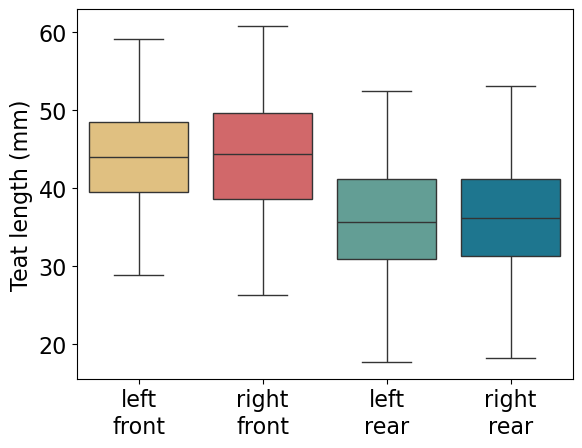

In [6]:

#create your own color array 
# my_colors = ["#666666",'#999999', "#016064",'#93D0C1'] 
my_colors = [ "#f0c571", '#e25759', "#59a89c", '#0b81a2'] 

# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
fig = plt.figure(figsize=(6.4, 4.8))
box_fig(data, "len", "", "Teat length (mm)")

plt.savefig(os.path.join(plot_dir,"teat_len_bplot.png"),bbox_inches='tight')

In [7]:
df2 = subset_df(data, "len")
df2 = df2[~np.isnan(df2.value)]
df2.groupby("variable").agg("count")

,cow,value
variable,,
lb,123,123
lf,113,113
rb,119,119
rf,120,120


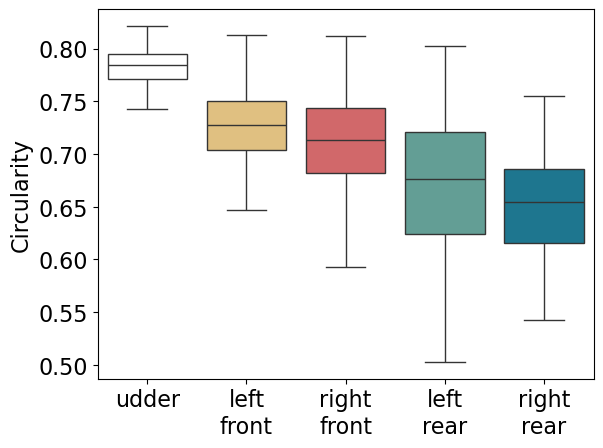

In [8]:
#create your own color array 
# my_colors = ["white","#666666",'#999999', "#016064",'#93D0C1'] 
my_colors = ["white", "#f0c571", '#e25759', "#59a89c", '#0b81a2']   
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
fig = plt.figure(figsize=(6.4, 4.8))
box_fig(data, "circ", "", "Circularity")
plt.savefig(os.path.join(plot_dir, "circ_bplot.png"),bbox_inches='tight')

In [9]:
df2 = subset_df(data, "circ")
df2 = df2[~np.isnan(df2.value)]
df2.groupby("variable").agg("count")

,cow,value
variable,,
lb,127,127
lf,118,118
rb,124,124
rf,125,125
udder,120,120


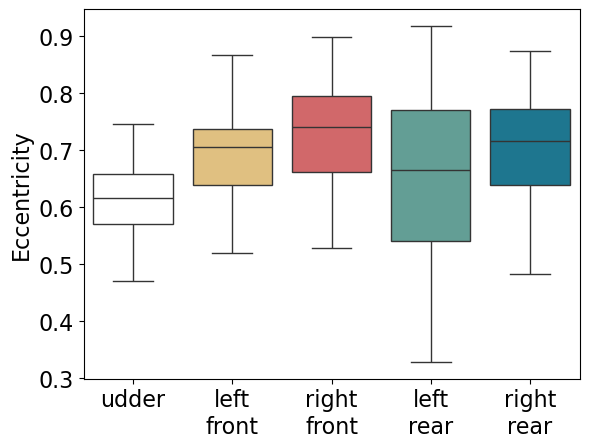

In [10]:
#create your own color array 
my_colors = ["white", "#f0c571", '#e25759', "#59a89c", '#0b81a2'] 

# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
fig = plt.figure(figsize=(6.4, 4.8))
box_fig(data, "exc", "", "Eccentricity")
plt.savefig(os.path.join(plot_dir, "ecc_bplot.png"),bbox_inches='tight')

In [11]:
df2 = subset_df(data, "exc")
df2 = df2[~np.isnan(df2.value)]
df2.groupby("variable").agg("count")

,cow,value
variable,,
lb,133,133
lf,119,119
rb,124,124
rf,128,128
udder,125,125


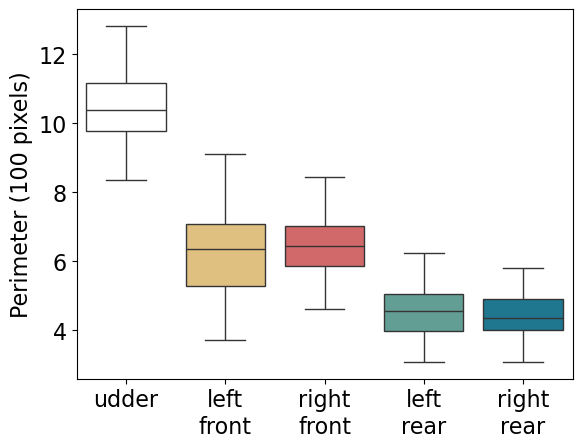

In [12]:
#create your own color array 
my_colors = ["white", "#f0c571", '#e25759', "#59a89c", '#0b81a2']  

# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
fig = plt.figure(figsize=(6.4, 4.8))
box_fig(data, "peri", "", "Perimeter (100 pixels)", 100)
plt.savefig(os.path.join(plot_dir, "peri_bplot.png"),bbox_inches='tight')

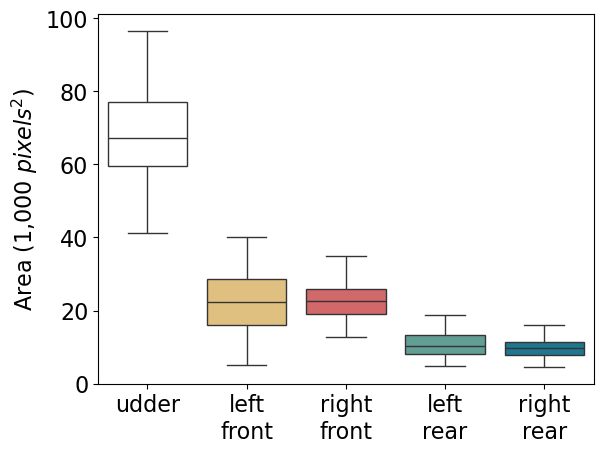

In [13]:
#create your own color array 
my_colors = ["white", "#f0c571", '#e25759', "#59a89c", '#0b81a2'] 

# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "area", "", "Area (1,000 $pixels^2$)", 1000)
plt.savefig(os.path.join(plot_dir, "area_bplot.png"),bbox_inches='tight')

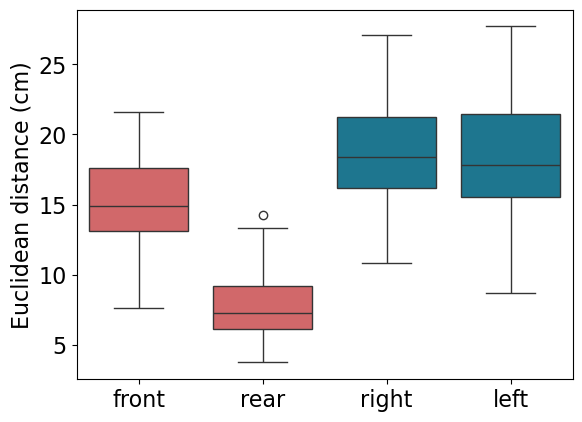

In [14]:
#create your own color array 
# my_colors = ['#999999', '#999999',  
#              "#016064", "#016064"] 
my_colors = ['#e25759', '#e25759','#0b81a2', '#0b81a2'] 
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "eu", "", "Euclidean distance (cm)")
plt.savefig(os.path.join(plot_dir, "eu_bplot.png"),bbox_inches='tight')

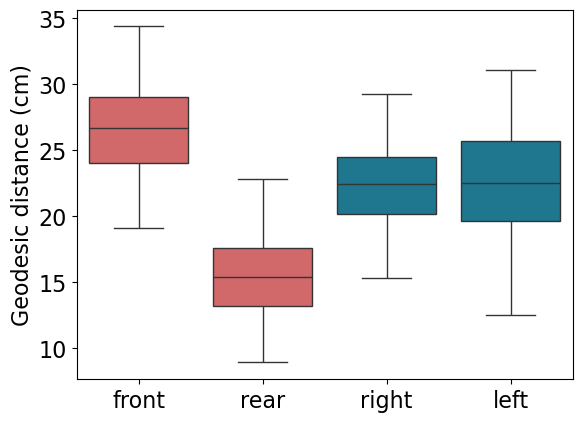

In [15]:
#create your own color array 
my_colors = ['#e25759', '#e25759','#0b81a2', '#0b81a2'] 
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "gd", "", "Geodesic distance (cm)")
plt.savefig(os.path.join(plot_dir, "gd_bplot.png"),bbox_inches='tight')

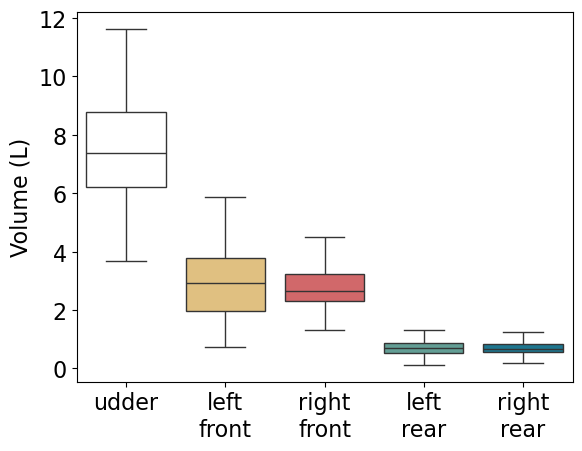

In [16]:
#create your own color array 
my_colors = ["white","#f0c571", '#e25759', "#59a89c", '#0b81a2']  
  
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "vol", "", "Volume (L)")
plt.savefig(os.path.join(plot_dir,"vol_bplot.png"),bbox_inches='tight')
# plt.savefig(os.path.join(plot_dir, "vol_bplot.png"),bbox_inches='tight')

In [17]:
df2 = subset_df(data, "vol")
df2 = df2[~np.isnan(df2.value)]
df2.groupby("variable").agg(
    mean=('value', np.mean),
    count=('value', "count"),
    std_=('value', np.std))

C:\Users\marie\AppData\Local\Temp\ipykernel_17228\422529017.py:3: FutureWarning:

The provided callable <function mean at 0x000001818CF75800> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

C:\Users\marie\AppData\Local\Temp\ipykernel_17228\422529017.py:3: FutureWarning:

The provided callable <function std at 0x000001818CF75940> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.



,mean,count,std_
variable,,,
lb,0.720089,118,0.243764
lf,2.940578,127,1.267339
rb,0.693389,117,0.220458
rf,2.788179,121,0.750434
udder,7.537096,128,1.790608


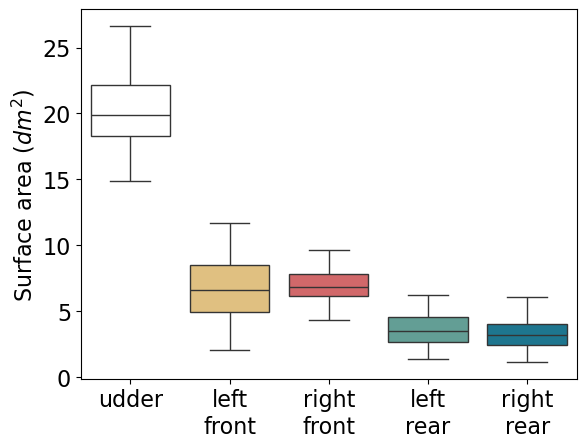

In [53]:
#create your own color array 
my_colors = ["white","#f0c571", '#e25759', "#59a89c", '#0b81a2']
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "sarea", "", "Surface area $(dm^2)$", 100)
plt.savefig(os.path.join(plot_dir, "sarea_bplot.png"),bbox_inches='tight')

In [54]:
merged = pd.read_csv(os.path.join(data_path, "lactation_features.csv"))

Text(0, 0.5, 'ylab')

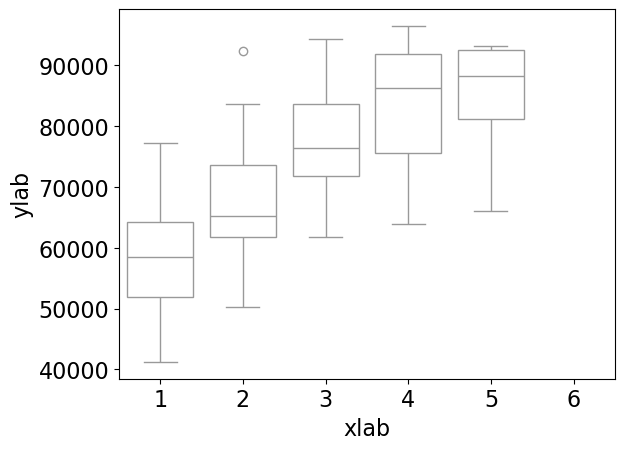

In [55]:
fig = sns.boxplot(y = merged['area_udder'], x = merged['lactation'])
# fig = sns.violinplot(y = group_df["value"]/frac, x = group_df["variable"], hue = group_df["variable"])
plt.xlabel("xlab")
plt.ylabel("ylab")

NameError: name 'xlab' is not defined

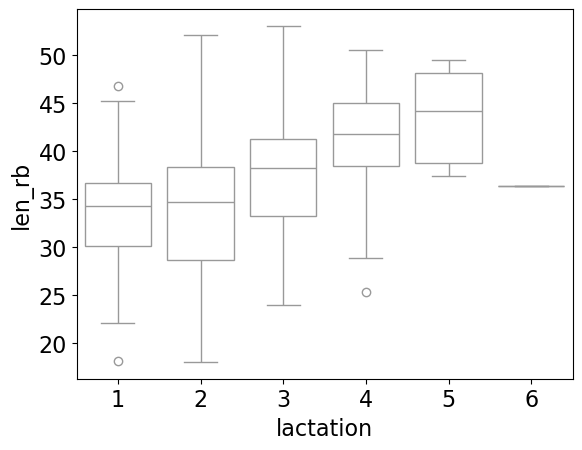

In [56]:
fig = sns.boxplot(y = merged['len_rb'], x = merged['lactation'])
# fig = sns.violinplot(y = group_df["value"]/frac, x = group_df["variable"], hue = group_df["variable"])
plt.xlabel(xlab)
plt.ylabel(ylab)